In [1]:
"""
Análise de Hipóteses - Home Credit Default Risk
=================================================
1. Carrega e trata a base (outliers/valores sentinela)
2. Testa hipóteses por eixo temático (demográfico, financeiro, emprego, bureau, pagamento interno)

Ajuste os caminhos (CAMINHO_TRAIN, CAMINHO_BUREAU, etc.) conforme sua pasta local.
"""

import pandas as pd
import numpy as np
import os
from scipy import stats
import json
import requests
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option("display.max_columns", None)

In [2]:
# ---------------------------------------------------------------------------
# 1. CARREGAMENTO
# ---------------------------------------------------------------------------
CAMINHO_TRAIN = "data/application_train.csv"
CAMINHO_BUREAU = "data/bureau.csv"
CAMINHO_INSTALLMENTS = "data/installments_payments.csv"
CAMINHO_PREVIOUS = "data/previous_application.csv"

df = pd.read_csv(CAMINHO_TRAIN)
print(f"Shape original: {df.shape}")

Shape original: (307511, 122)


In [3]:
# ---------------------------------------------------------------------------
# 2. TRATAMENTO DE OUTLIERS / VALORES SENTINELA
# ---------------------------------------------------------------------------
def tratar_outliers(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # DAYS_EMPLOYED tem o valor sentinela 365243 (~1000 anos) para
    # aposentados/desempregados -- não é outlier real, é código de erro do
    # sistema de origem. Convertido para NaN.
    if "DAYS_EMPLOYED" in df.columns:
        df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)

    # DAYS_BIRTH, DAYS_EMPLOYED, DAYS_REGISTRATION, DAYS_ID_PUBLISH vêm
    # negativos (dias antes da aplicação). Convertendo para anos/positivo
    # facilita leitura e evita erro de sinal em comparações.
    for col in ["DAYS_BIRTH", "DAYS_EMPLOYED", "DAYS_REGISTRATION", "DAYS_ID_PUBLISH"]:
        if col in df.columns:
            df[col] = df[col].abs()
    if "DAYS_BIRTH" in df.columns:
        df["AGE_YEARS"] = df["DAYS_BIRTH"] / 365.25
    if "DAYS_EMPLOYED" in df.columns:
        df["EMPLOYED_YEARS"] = df["DAYS_EMPLOYED"] / 365.25

    # AMT_INCOME_TOTAL tem outliers extremos (ex: valores acima de 100 milhões
    # em poucas linhas) que distorcem qualquer teste. Cap no percentil 99.5.
    if "AMT_INCOME_TOTAL" in df.columns:
        limite = df["AMT_INCOME_TOTAL"].quantile(0.995)
        antes = (df["AMT_INCOME_TOTAL"] > limite).sum()
        df["AMT_INCOME_TOTAL"] = df["AMT_INCOME_TOTAL"].clip(upper=limite)
        print(f"AMT_INCOME_TOTAL: {antes} valores acima do p99.5 ({limite:,.0f}) limitados (winsorização)")

    # CNT_CHILDREN e CNT_FAM_MEMBERS têm alguns valores absurdos (ex: 19 filhos)
    for col in ["CNT_CHILDREN", "CNT_FAM_MEMBERS"]:
        if col in df.columns:
            limite = df[col].quantile(0.999)
            antes = (df[col] > limite).sum()
            df[col] = df[col].clip(upper=limite)
            if antes:
                print(f"{col}: {antes} valores acima do p99.9 limitados")

    # Razão crédito/renda -- feature derivada útil para a hipótese financeira
    if {"AMT_CREDIT", "AMT_INCOME_TOTAL"}.issubset(df.columns):
        df["CREDIT_INCOME_RATIO"] = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]

    return df


df = tratar_outliers(df)
print(f"Shape após tratamento: {df.shape}\n")

AMT_INCOME_TOTAL: 1446 valores acima do p99.5 (630,000) limitados (winsorização)
CNT_CHILDREN: 126 valores acima do p99.9 limitados
CNT_FAM_MEMBERS: 121 valores acima do p99.9 limitados
Shape após tratamento: (307511, 125)



In [4]:
# ---------------------------------------------------------------------------
# 3. CONFIGURAÇÃO DO DEEPSEEK
# ---------------------------------------------------------------------------
class DeepSeekClient:
    def __init__(self, api_key: str = None, model: str = "deepseek-chat"):
        self.api_key = api_key or os.getenv("DEEPSEEK_API_KEY")
        self.model = model
        self.base_url = "https://api.deepseek.com/chat/completions"

    def chat(self, messages, temperature=0.7, max_tokens=2000):
        """Envia uma mensagem para a DeepSeek"""
        if not self.api_key:
            return "❌ Chave DEEPSEEK_API_KEY não encontrada!"

        headers = {
            "Authorization": f"Bearer {self.api_key}",
            "Content-Type": "application/json"
        }

        data = {
            "model": self.model,
            "messages": messages,
            "temperature": temperature,
            "max_tokens": max_tokens
        }

        try:
            response = requests.post(self.base_url, headers=headers, json=data)
            response.raise_for_status()
            resultado = response.json()
            return resultado['choices'][0]['message']['content']
        except Exception as e:
            return f"❌ Erro na API: {str(e)}"


# Inicializar cliente
cliente = DeepSeekClient()

In [5]:
# ---------------------------------------------------------------------------
# 4. FUNÇÕES DE TESTE
# ---------------------------------------------------------------------------
def interpretar_cramers_v(v):
    if v < 0.10:
        return "efeito desprezível"
    elif v < 0.20:
        return "efeito fraco"
    elif v < 0.40:
        return "efeito moderado"
    else:
        return "efeito forte"


def testar_categorica(df, coluna, target="TARGET", alpha=0.05):
    """Qui-quadrado: associação entre variável categórica e TARGET.
    Tamanho de efeito: Cramér's V (0=nenhuma associação, 1=associação perfeita).
    Necessário porque com ~300k linhas quase tudo dá p-valor baixo -- o V mostra
    se a associação é forte o suficiente para importar na prática."""
    tabela = pd.crosstab(df[coluna], df[target])
    chi2, p, dof, _ = stats.chi2_contingency(tabela)
    n = tabela.sum().sum()
    k = min(tabela.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * k)) if k > 0 else np.nan
    print(f"[Qui-quadrado] {coluna} vs {target}")
    print(f"  chi2={chi2:.2f}  p-valor={p:.4g}  -> {'REJEITA H0 (associação significativa)' if p < alpha else 'não rejeita H0'}")
    print(f"  Cramér's V={cramers_v:.4f}  -> {interpretar_cramers_v(cramers_v)}\n")
    return p, cramers_v


def interpretar_r(r):
    r = abs(r)
    if r < 0.10:
        return "efeito desprezível"
    elif r < 0.30:
        return "efeito pequeno"
    elif r < 0.50:
        return "efeito moderado"
    else:
        return "efeito grande"


def testar_numerica(df, coluna, target="TARGET", alpha=0.05):
    """Mann-Whitney U: compara distribuição da variável numérica entre TARGET=0 e TARGET=1.
    Preferido ao teste t por não assumir normalidade (essas variáveis costumam ser assimétricas).
    Tamanho de efeito: r rank-biserial (-1 a 1). Com ~300k linhas o p-valor quase
    sempre vem ~0 -- o r mostra se a diferença é grande o suficiente pra importar."""
    grupo0 = df.loc[df[target] == 0, coluna].dropna()
    grupo1 = df.loc[df[target] == 1, coluna].dropna()
    n0, n1 = len(grupo0), len(grupo1)
    stat, p = stats.mannwhitneyu(grupo0, grupo1, alternative="two-sided")
    # r rank-biserial = 1 - (2*U) / (n0*n1), onde U é a estatística do grupo0
    r = 1 - (2 * stat) / (n0 * n1)
    print(f"[Mann-Whitney] {coluna} vs {target}")
    print(f"  mediana TARGET=0: {grupo0.median():.2f}  |  mediana TARGET=1: {grupo1.median():.2f}")
    print(f"  p-valor={p:.4g}  -> {'REJEITA H0 (diferença significativa)' if p < alpha else 'não rejeita H0'}")
    print(f"  r rank-biserial={r:.4f}  -> {interpretar_r(r)}\n")
    return p, r

In [6]:
# ===========================================================================
# 5. FUNÇÕES DE VISUALIZAÇÃO
# ===========================================================================

def criar_graficos_demograficos(df):
    """Gráficos do Eixo 1: Demográficas"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Distribuição de idade por TARGET
    ax1 = axes[0, 0]
    for target in [0, 1]:
        dados = df[df['TARGET'] == target]['AGE_YEARS'].dropna()
        ax1.hist(dados, bins=40, alpha=0.6, label=f'TARGET={target}', density=True)
    ax1.set_xlabel('Idade (anos)')
    ax1.set_ylabel('Densidade')
    ax1.set_title('Distribuição de Idade por Status de Default')
    ax1.legend()
    ax1.axvline(df[df['TARGET']==0]['AGE_YEARS'].median(), color='blue', linestyle='--', alpha=0.5)
    ax1.axvline(df[df['TARGET']==1]['AGE_YEARS'].median(), color='orange', linestyle='--', alpha=0.5)
    
    # 2. Taxa de default por faixa etária
    ax2 = axes[0, 1]
    df['AGE_GROUP'] = pd.cut(df['AGE_YEARS'], bins=[0, 25, 35, 45, 55, 65, 100], 
                             labels=['<25', '25-35', '35-45', '45-55', '55-65', '65+'])
    taxa_default = df.groupby('AGE_GROUP', observed=True)['TARGET'].mean() * 100
    taxa_default.plot(kind='bar', ax=ax2, color='coral', edgecolor='black')
    ax2.set_xlabel('Faixa Etária')
    ax2.set_ylabel('Taxa de Default (%)')
    ax2.set_title('Taxa de Default por Faixa Etária')
    ax2.axhline(df['TARGET'].mean()*100, color='red', linestyle='--', label='Média Global')
    ax2.legend()
    
    # 3. Taxa de default por escolaridade
    ax3 = axes[1, 0]
    educ_order = df.groupby('NAME_EDUCATION_TYPE', observed=True)['TARGET'].mean().sort_values().index
    taxa_educ = df.groupby('NAME_EDUCATION_TYPE', observed=True)['TARGET'].mean() * 100
    taxa_educ.loc[educ_order].plot(kind='barh', ax=ax3, color='skyblue', edgecolor='black')
    ax3.set_xlabel('Taxa de Default (%)')
    ax3.set_ylabel('Nível Educacional')
    ax3.set_title('Taxa de Default por Nível Educacional')
    ax3.axvline(df['TARGET'].mean()*100, color='red', linestyle='--', label='Média Global')
    ax3.legend()
    
    # 4. Taxa de default por estado civil
    ax4 = axes[1, 1]
    family_order = df.groupby('NAME_FAMILY_STATUS', observed=True)['TARGET'].mean().sort_values().index
    taxa_family = df.groupby('NAME_FAMILY_STATUS', observed=True)['TARGET'].mean() * 100
    taxa_family.loc[family_order].plot(kind='barh', ax=ax4, color='lightgreen', edgecolor='black')
    ax4.set_xlabel('Taxa de Default (%)')
    ax4.set_ylabel('Estado Civil')
    ax4.set_title('Taxa de Default por Estado Civil')
    ax4.axvline(df['TARGET'].mean()*100, color='red', linestyle='--', label='Média Global')
    ax4.legend()
    
    plt.tight_layout()
    plt.show()
    
    return fig

def criar_graficos_financeiros(df):
    """Gráficos do Eixo 2: Financeiras"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Boxplot da razão crédito/renda
    ax1 = axes[0, 0]
    df_box = df[['TARGET', 'CREDIT_INCOME_RATIO']].dropna()
    df_box.boxplot(column='CREDIT_INCOME_RATIO', by='TARGET', ax=ax1)
    ax1.set_title('Razão Crédito/Renda por Status de Default')
    ax1.set_xlabel('TARGET')
    ax1.set_ylabel('Crédito / Renda')
    
    # 2. Taxa de default por tipo de contrato
    ax2 = axes[0, 1]
    contrato_order = df.groupby('NAME_CONTRACT_TYPE', observed=True)['TARGET'].mean().sort_values().index
    taxa_contrato = df.groupby('NAME_CONTRACT_TYPE', observed=True)['TARGET'].mean() * 100
    taxa_contrato.loc[contrato_order].plot(kind='bar', ax=ax2, color='purple', edgecolor='black')
    ax2.set_xlabel('Tipo de Contrato')
    ax2.set_ylabel('Taxa de Default (%)')
    ax2.set_title('Taxa de Default por Tipo de Contrato')
    ax2.axhline(df['TARGET'].mean()*100, color='red', linestyle='--', label='Média Global')
    ax2.legend()
    
    # 3. Taxa de default por tipo de renda
    ax3 = axes[1, 0]
    renda_order = df.groupby('NAME_INCOME_TYPE', observed=True)['TARGET'].mean().sort_values().index
    taxa_renda = df.groupby('NAME_INCOME_TYPE', observed=True)['TARGET'].mean() * 100
    taxa_renda.loc[renda_order].plot(kind='barh', ax=ax3, color='teal', edgecolor='black')
    ax3.set_xlabel('Taxa de Default (%)')
    ax3.set_ylabel('Tipo de Renda')
    ax3.set_title('Taxa de Default por Tipo de Renda')
    ax3.axvline(df['TARGET'].mean()*100, color='red', linestyle='--', label='Média Global')
    ax3.legend()
    
    # 4. Distribuição do EXT_SOURCE_3
    ax4 = axes[1, 1]
    for target in [0, 1]:
        dados = df[df['TARGET'] == target]['EXT_SOURCE_3'].dropna()
        ax4.hist(dados, bins=30, alpha=0.6, label=f'TARGET={target}', density=True)
    ax4.set_xlabel('EXT_SOURCE_3')
    ax4.set_ylabel('Densidade')
    ax4.set_title('Distribuição do EXT_SOURCE_3 por Status de Default')
    ax4.legend()
    
    plt.tight_layout()
    plt.show()
    
    return fig

def criar_graficos_emprego(df):
    """Gráficos do Eixo 3: Emprego e Estabilidade"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # 1. Boxplot de tempo de emprego
    ax1 = axes[0]
    df_box = df[['TARGET', 'EMPLOYED_YEARS']].dropna()
    df_box.boxplot(column='EMPLOYED_YEARS', by='TARGET', ax=ax1)
    ax1.set_title('Tempo de Emprego por Status de Default')
    ax1.set_xlabel('TARGET')
    ax1.set_ylabel('Anos de Emprego')
    
    # 2. Taxa de default por ocupação
    ax2 = axes[1]
    # Filtrar ocupações com pelo menos 1000 observações
    occ_counts = df['OCCUPATION_TYPE'].value_counts()
    occ_filt = occ_counts[occ_counts >= 1000].index
    df_filt = df[df['OCCUPATION_TYPE'].isin(occ_filt)]
    
    occ_order = df_filt.groupby('OCCUPATION_TYPE', observed=True)['TARGET'].mean().sort_values().index
    taxa_occ = df_filt.groupby('OCCUPATION_TYPE', observed=True)['TARGET'].mean() * 100
    taxa_occ.loc[occ_order].plot(kind='barh', ax=ax2, color='orange', edgecolor='black')
    ax2.set_xlabel('Taxa de Default (%)')
    ax2.set_ylabel('Ocupação')
    ax2.set_title('Taxa de Default por Ocupação (≥1000 clientes)')
    ax2.axvline(df['TARGET'].mean()*100, color='red', linestyle='--', label='Média Global')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    return fig

def criar_graficos_bureau(df):
    """Gráficos do Eixo 4: Histórico Bureau"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # 1. Taxa de default por atraso no bureau
    ax1 = axes[0]
    atraso_order = df.groupby('TEVE_ATRASO_BUREAU', observed=True)['TARGET'].mean().sort_values().index
    taxa_atraso = df.groupby('TEVE_ATRASO_BUREAU', observed=True)['TARGET'].mean() * 100
    taxa_atraso.loc[atraso_order].plot(kind='bar', ax=ax1, color=['green', 'red'], edgecolor='black')
    ax1.set_xlabel('Teve Atraso no Bureau')
    ax1.set_ylabel('Taxa de Default (%)')
    ax1.set_title('Taxa de Default por Histórico de Atraso no Bureau')
    ax1.axhline(df['TARGET'].mean()*100, color='blue', linestyle='--', label='Média Global')
    ax1.legend()
    
    # 2. Distribuição de créditos ativos por TARGET
    ax2 = axes[1]
    for target in [0, 1]:
        dados = df[df['TARGET'] == target]['QTD_CREDITOS_ATIVOS']
        ax2.hist(dados, bins=range(0, 11), alpha=0.6, label=f'TARGET={target}', density=True)
    ax2.set_xlabel('Número de Créditos Ativos')
    ax2.set_ylabel('Densidade')
    ax2.set_title('Distribuição de Créditos Ativos por Status de Default')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    return fig

def criar_graficos_pagamento(df):
    """Gráficos do Eixo 5: Comportamento de Pagamento Interno"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # 1. Taxa de default por pedido recusado
    ax1 = axes[0]
    recusado_order = df.groupby('TEVE_PEDIDO_RECUSADO', observed=True)['TARGET'].mean().sort_values().index
    taxa_recusado = df.groupby('TEVE_PEDIDO_RECUSADO', observed=True)['TARGET'].mean() * 100
    taxa_recusado.loc[recusado_order].plot(kind='bar', ax=ax1, color=['green', 'red'], edgecolor='black')
    ax1.set_xlabel('Teve Pedido Recusado')
    ax1.set_ylabel('Taxa de Default (%)')
    ax1.set_title('Taxa de Default por Histórico de Pedidos Recusados')
    ax1.axhline(df['TARGET'].mean()*100, color='blue', linestyle='--', label='Média Global')
    ax1.legend()
    
    # 2. Boxplot de atraso médio
    ax2 = axes[1]
    df_box = df[['TARGET', 'ATRASO_MEDIO_DIAS']].dropna()
    df_box.boxplot(column='ATRASO_MEDIO_DIAS', by='TARGET', ax=ax2)
    ax2.set_title('Atraso Médio em Parcelas por Status de Default')
    ax2.set_xlabel('TARGET')
    ax2.set_ylabel('Atraso Médio (dias)')
    
    plt.tight_layout()
    plt.show()
    
    return fig

def criar_heatmap_correlacao(df):
    """Heatmap de correlação das principais variáveis com TARGET"""
    # Selecionar variáveis numéricas relevantes
    vars_correlacao = [
        'TARGET', 'AGE_YEARS', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 
        'AMT_CREDIT', 'CREDIT_INCOME_RATIO', 'EMPLOYED_YEARS',
        'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
        'QTD_CREDITOS_BUREAU', 'QTD_CREDITOS_ATIVOS', 'QTD_PEDIDOS_RECUSADOS'
    ]
    
    # Filtrar colunas existentes
    vars_existentes = [v for v in vars_correlacao if v in df.columns]
    df_corr = df[vars_existentes].corr()
    
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(df_corr, dtype=bool))
    sns.heatmap(df_corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
                center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title('Matriz de Correlação com TARGET')
    plt.tight_layout()
    plt.show()

def criar_grafico_resumo_efeitos(resultados_testes):
    """Gráfico de barras resumindo os tamanhos de efeito"""
    # Separar variáveis por tipo de teste
    vars_categoricas = {k: v for k, v in resultados_testes.items() if v['tipo'] == 'categorica'}
    vars_numericas = {k: v for k, v in resultados_testes.items() if v['tipo'] == 'numerica'}
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Gráfico para variáveis categóricas (Cramér's V)
    ax1 = axes[0]
    if vars_categoricas:
        nomes = list(vars_categoricas.keys())
        valores = [v['efeito'] for v in vars_categoricas.values()]
        cores = ['green' if v < 0.1 else 'yellow' if v < 0.2 else 'orange' if v < 0.4 else 'red' 
                 for v in valores]
        bars = ax1.barh(nomes, valores, color=cores, edgecolor='black')
        ax1.axvline(0.1, color='green', linestyle='--', alpha=0.5, label='desprezível')
        ax1.axvline(0.2, color='orange', linestyle='--', alpha=0.5, label='fraco')
        ax1.axvline(0.4, color='red', linestyle='--', alpha=0.5, label='moderado')
        ax1.set_xlabel("Cramér's V")
        ax1.set_title('Tamanho de Efeito - Variáveis Categóricas')
        ax1.legend()
        ax1.grid(axis='x', alpha=0.3)
    
    # Gráfico para variáveis numéricas (r rank-biserial)
    ax2 = axes[1]
    if vars_numericas:
        nomes = list(vars_numericas.keys())
        valores = [abs(v['efeito']) for v in vars_numericas.values()]
        cores = ['green' if v < 0.1 else 'yellow' if v < 0.3 else 'orange' if v < 0.5 else 'red' 
                 for v in valores]
        bars = ax2.barh(nomes, valores, color=cores, edgecolor='black')
        ax2.axvline(0.1, color='green', linestyle='--', alpha=0.5, label='desprezível')
        ax2.axvline(0.3, color='orange', linestyle='--', alpha=0.5, label='pequeno')
        ax2.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='moderado')
        ax2.set_xlabel("|r rank-biserial|")
        ax2.set_title('Tamanho de Efeito - Variáveis Numéricas')
        ax2.legend()
        ax2.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

EIXO 1: DEMOGRÁFICAS

📊 Gerando gráficos demográficos...


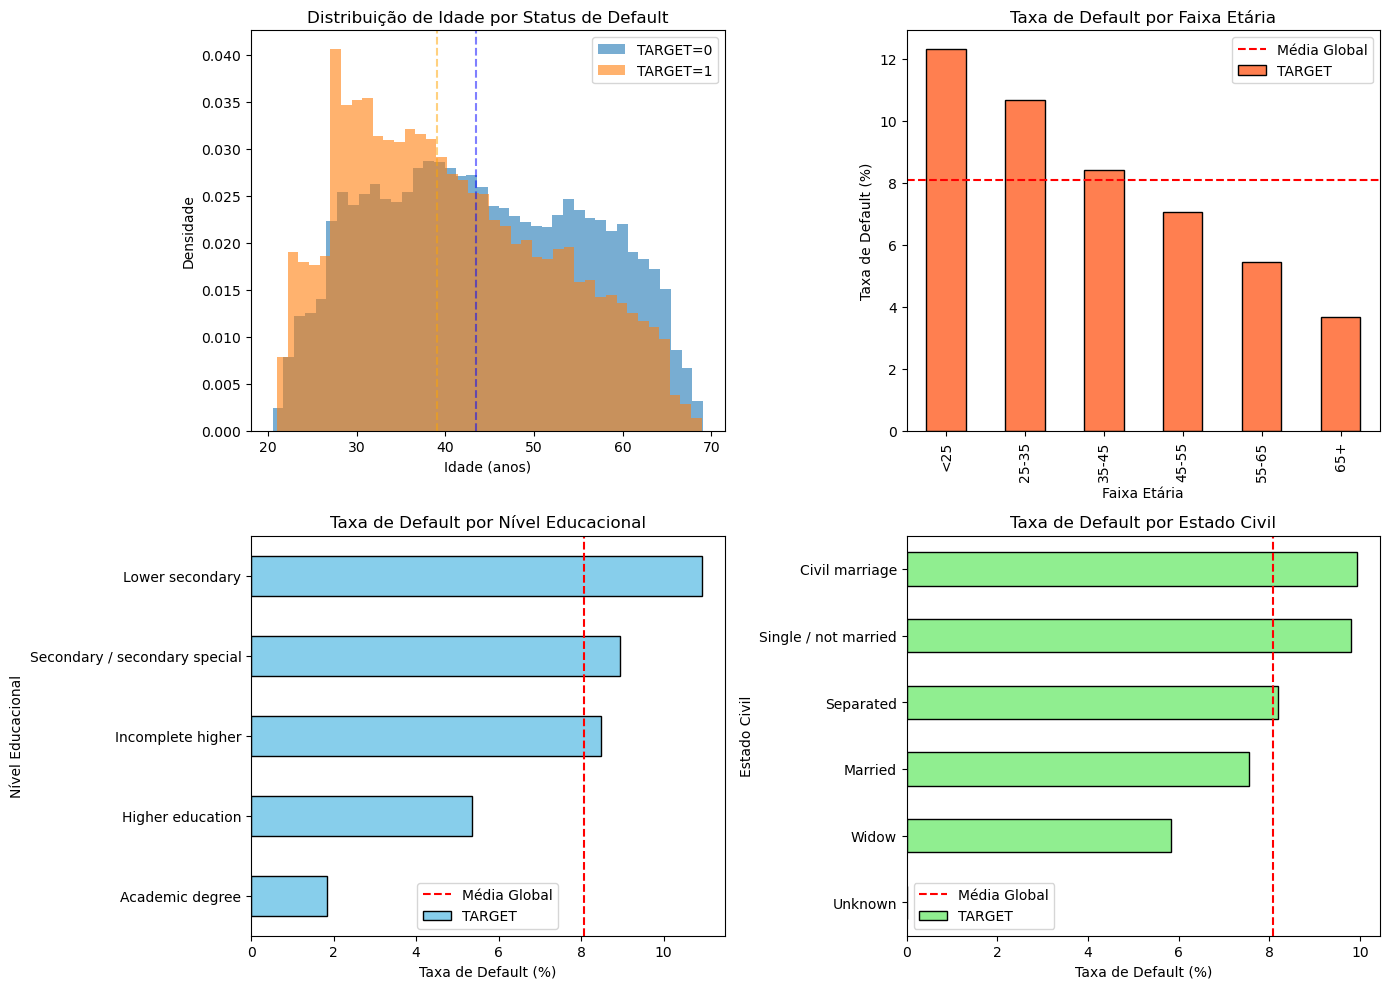

[Mann-Whitney] AGE_YEARS vs TARGET
  mediana TARGET=0: 43.47  |  mediana TARGET=1: 39.10
  p-valor=0  -> REJEITA H0 (diferença significativa)
  r rank-biserial=-0.1660  -> efeito pequeno

[Qui-quadrado] NAME_EDUCATION_TYPE vs TARGET
  chi2=1019.21  p-valor=2.448e-219  -> REJEITA H0 (associação significativa)
  Cramér's V=0.0576  -> efeito desprezível

[Mann-Whitney] CNT_CHILDREN vs TARGET
  mediana TARGET=0: 0.00  |  mediana TARGET=1: 0.00
  p-valor=8.765e-29  -> REJEITA H0 (diferença significativa)
  r rank-biserial=0.0342  -> efeito desprezível

[Qui-quadrado] NAME_FAMILY_STATUS vs TARGET
  chi2=504.69  p-valor=7.745e-107  -> REJEITA H0 (associação significativa)
  Cramér's V=0.0405  -> efeito desprezível


EIXO 2: FINANCEIRAS

📊 Gerando gráficos financeiros...


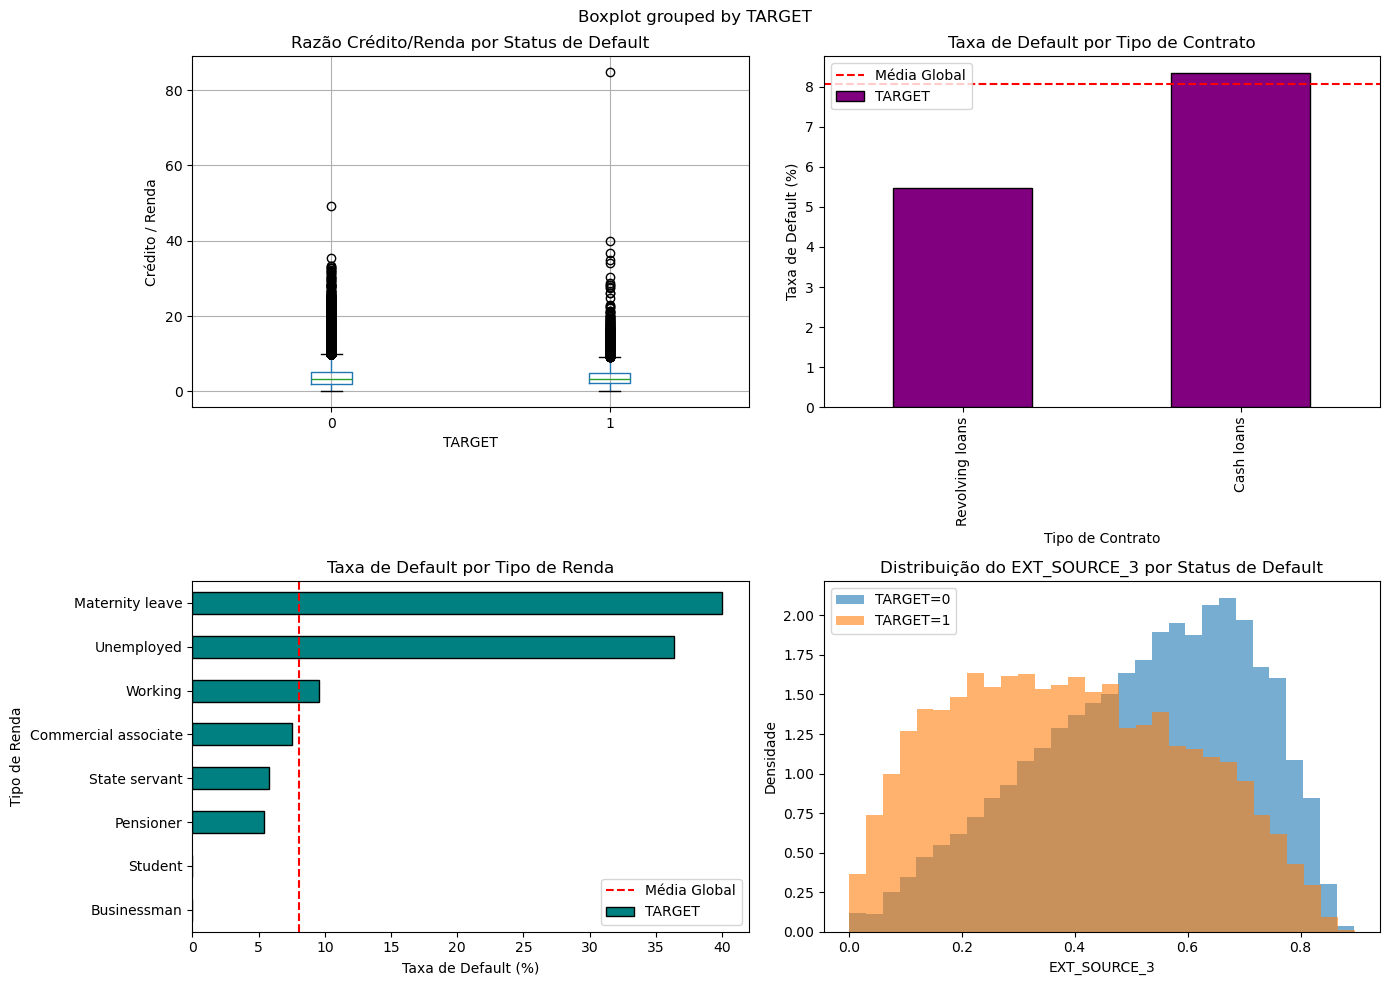

[Mann-Whitney] CREDIT_INCOME_RATIO vs TARGET
  mediana TARGET=0: 3.27  |  mediana TARGET=1: 3.25
  p-valor=0.2751  -> não rejeita H0
  r rank-biserial=-0.0042  -> efeito desprezível

[Qui-quadrado] NAME_CONTRACT_TYPE vs TARGET
  chi2=293.15  p-valor=1.024e-65  -> REJEITA H0 (associação significativa)
  Cramér's V=0.0309  -> efeito desprezível

[Qui-quadrado] NAME_INCOME_TYPE vs TARGET
  chi2=1253.47  p-valor=1.928e-266  -> REJEITA H0 (associação significativa)
  Cramér's V=0.0638  -> efeito desprezível

[Mann-Whitney] EXT_SOURCE_1 vs TARGET
  mediana TARGET=0: 0.52  |  mediana TARGET=1: 0.36
  p-valor=0  -> REJEITA H0 (diferença significativa)
  r rank-biserial=-0.3314  -> efeito moderado

[Mann-Whitney] EXT_SOURCE_2 vs TARGET
  mediana TARGET=0: 0.57  |  mediana TARGET=1: 0.44
  p-valor=0  -> REJEITA H0 (diferença significativa)
  r rank-biserial=-0.3122  -> efeito moderado

[Mann-Whitney] EXT_SOURCE_3 vs TARGET
  mediana TARGET=0: 0.55  |  mediana TARGET=1: 0.38
  p-valor=0  -> REJEI

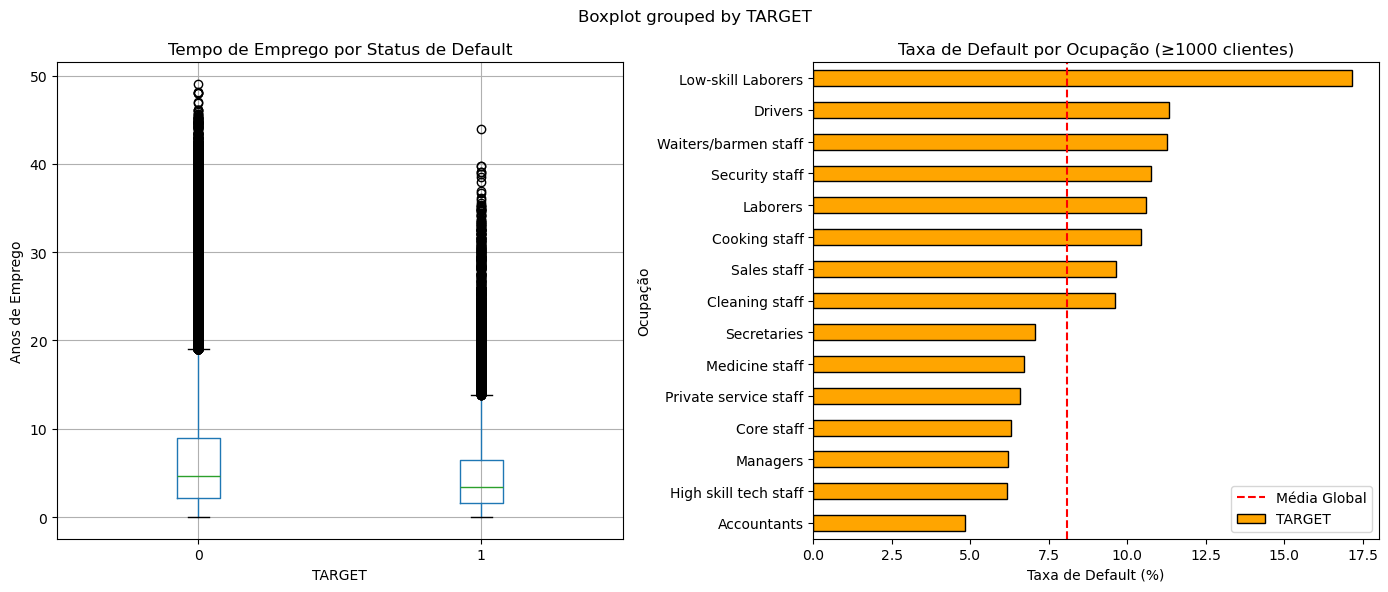

[Mann-Whitney] EMPLOYED_YEARS vs TARGET
  mediana TARGET=0: 4.63  |  mediana TARGET=1: 3.37
  p-valor=0  -> REJEITA H0 (diferença significativa)
  r rank-biserial=-0.1648  -> efeito pequeno

[Qui-quadrado] OCCUPATION_TYPE vs TARGET
  chi2=1402.85  p-valor=3.784e-288  -> REJEITA H0 (associação significativa)
  Cramér's V=0.0815  -> efeito desprezível


EIXO 4: HISTÓRICO EXTERNO (BUREAU)

📊 Gerando gráficos do bureau...


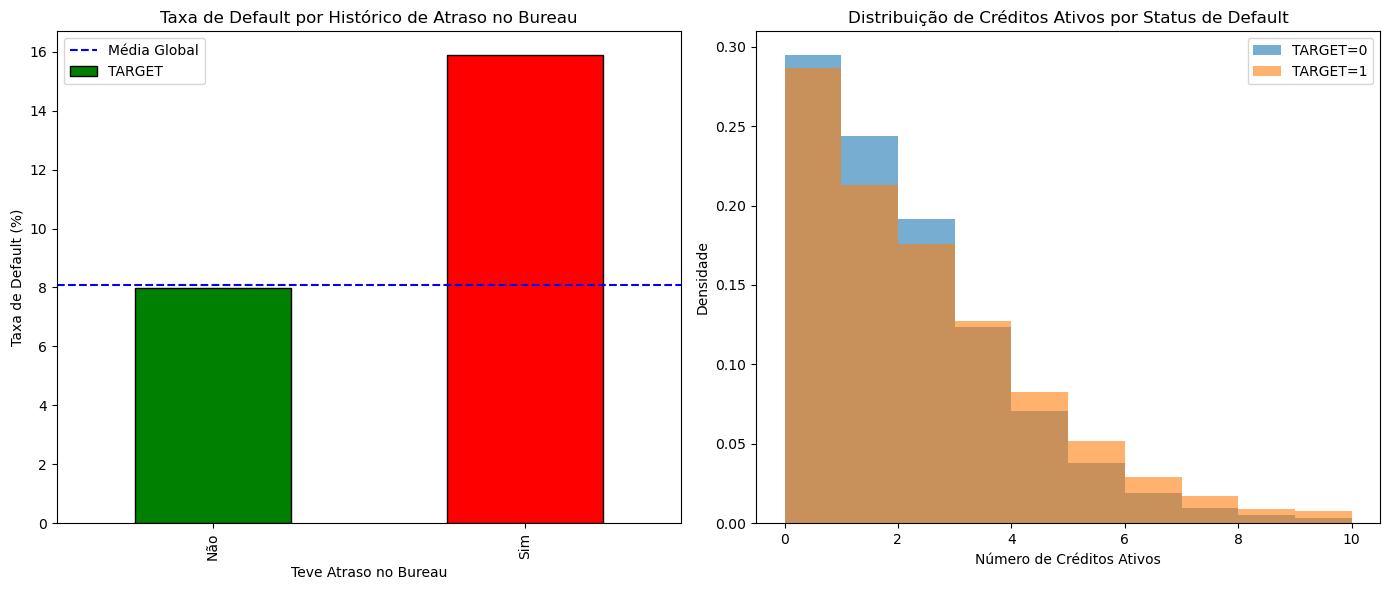

[Qui-quadrado] TEVE_ATRASO_BUREAU vs TARGET
  chi2=282.24  p-valor=2.444e-63  -> REJEITA H0 (associação significativa)
  Cramér's V=0.0303  -> efeito desprezível

[Mann-Whitney] QTD_CREDITOS_ATIVOS vs TARGET
  mediana TARGET=0: 1.00  |  mediana TARGET=1: 2.00
  p-valor=8.552e-56  -> REJEITA H0 (diferença significativa)
  r rank-biserial=0.0587  -> efeito desprezível


EIXO 5: COMPORTAMENTO DE PAGAMENTO INTERNO

📊 Gerando gráficos de pagamento...


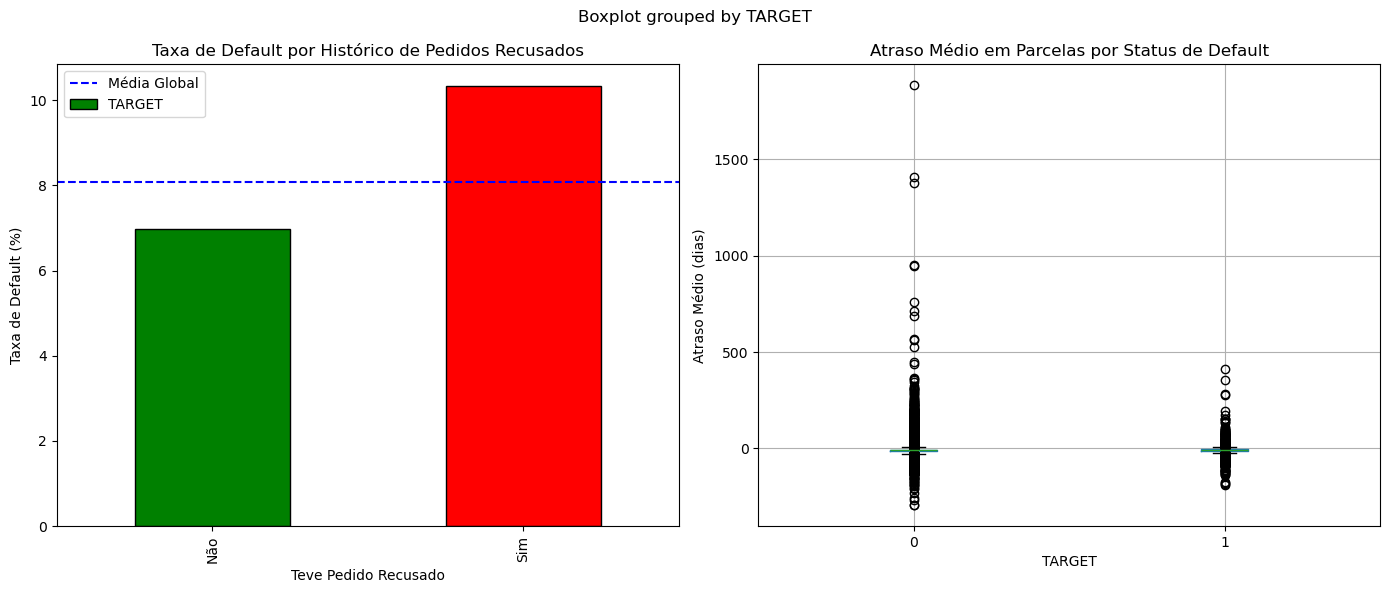

[Qui-quadrado] TEVE_PEDIDO_RECUSADO vs TARGET
  chi2=1013.76  p-valor=1.831e-222  -> REJEITA H0 (associação significativa)
  Cramér's V=0.0574  -> efeito desprezível

[Mann-Whitney] ATRASO_MEDIO_DIAS vs TARGET
  mediana TARGET=0: -9.62  |  mediana TARGET=1: -8.63
  p-valor=3.638e-106  -> REJEITA H0 (diferença significativa)
  r rank-biserial=0.0853  -> efeito desprezível



In [7]:
# ---------------------------------------------------------------------------
# 6. TESTE DAS HIPÓTESES POR EIXO COM VISUALIZAÇÕES
# ---------------------------------------------------------------------------
resultados_testes = {}

print("=" * 70)
print("EIXO 1: DEMOGRÁFICAS")
print("=" * 70)
print("\n📊 Gerando gráficos demográficos...")
criar_graficos_demograficos(df)

p, r = testar_numerica(df, "AGE_YEARS")
resultados_testes["Idade"] = {"p": p, "efeito": r, "tipo": "numerica"}

p, v = testar_categorica(df, "NAME_EDUCATION_TYPE")
resultados_testes["Escolaridade"] = {"p": p, "efeito": v, "tipo": "categorica"}

p, r = testar_numerica(df, "CNT_CHILDREN")
resultados_testes["Número de filhos"] = {"p": p, "efeito": r, "tipo": "numerica"}

p, v = testar_categorica(df, "NAME_FAMILY_STATUS")
resultados_testes["Estado civil"] = {"p": p, "efeito": v, "tipo": "categorica"}

print("\n" + "=" * 70)
print("EIXO 2: FINANCEIRAS")
print("=" * 70)
print("\n📊 Gerando gráficos financeiros...")
criar_graficos_financeiros(df)

p, r = testar_numerica(df, "CREDIT_INCOME_RATIO")
resultados_testes["Razão crédito/renda"] = {"p": p, "efeito": r, "tipo": "numerica"}

p, v = testar_categorica(df, "NAME_CONTRACT_TYPE")
resultados_testes["Tipo de contrato"] = {"p": p, "efeito": v, "tipo": "categorica"}

p, v = testar_categorica(df, "NAME_INCOME_TYPE")
resultados_testes["Tipo de renda"] = {"p": p, "efeito": v, "tipo": "categorica"}

for col in ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]:
    if col in df.columns:
        p, r = testar_numerica(df, col)
        resultados_testes[col] = {"p": p, "efeito": r, "tipo": "numerica"}

print("\n" + "=" * 70)
print("EIXO 3: EMPREGO E ESTABILIDADE")
print("=" * 70)
print("\n📊 Gerando gráficos de emprego...")
criar_graficos_emprego(df)

p, r = testar_numerica(df, "EMPLOYED_YEARS")
resultados_testes["Tempo de emprego"] = {"p": p, "efeito": r, "tipo": "numerica"}

p, v = testar_categorica(df, "OCCUPATION_TYPE")
resultados_testes["Ocupação"] = {"p": p, "efeito": v, "tipo": "categorica"}

print("\n" + "=" * 70)
print("EIXO 4: HISTÓRICO EXTERNO (BUREAU)")
print("=" * 70)

bureau = pd.read_csv(CAMINHO_BUREAU)
agg_bureau = bureau.groupby("SK_ID_CURR").agg(
    MAX_CREDIT_DAY_OVERDUE=("CREDIT_DAY_OVERDUE", "max"),
    QTD_CREDITOS_BUREAU=("SK_ID_BUREAU", "count"),
    QTD_CREDITOS_ATIVOS=("CREDIT_ACTIVE", lambda x: (x == "Active").sum()),
).reset_index()

df = df.merge(agg_bureau, on="SK_ID_CURR", how="left")
df["MAX_CREDIT_DAY_OVERDUE"] = df["MAX_CREDIT_DAY_OVERDUE"].fillna(0)
df["QTD_CREDITOS_BUREAU"] = df["QTD_CREDITOS_BUREAU"].fillna(0)
df["QTD_CREDITOS_ATIVOS"] = df["QTD_CREDITOS_ATIVOS"].fillna(0)

df["TEVE_ATRASO_BUREAU"] = (df["MAX_CREDIT_DAY_OVERDUE"] > 0).map({True: "Sim", False: "Não"})

print("\n📊 Gerando gráficos do bureau...")
criar_graficos_bureau(df)

p, v = testar_categorica(df, "TEVE_ATRASO_BUREAU")
resultados_testes["Teve atraso no bureau"] = {"p": p, "efeito": v, "tipo": "categorica"}

p, r = testar_numerica(df, "QTD_CREDITOS_ATIVOS")
resultados_testes["Qtd. créditos ativos"] = {"p": p, "efeito": r, "tipo": "numerica"}

print("\n" + "=" * 70)
print("EIXO 5: COMPORTAMENTO DE PAGAMENTO INTERNO")
print("=" * 70)

previous = pd.read_csv(CAMINHO_PREVIOUS)
installments = pd.read_csv(CAMINHO_INSTALLMENTS)

agg_previous = previous.groupby("SK_ID_CURR").agg(
    QTD_PEDIDOS_RECUSADOS=("NAME_CONTRACT_STATUS", lambda x: (x == "Refused").sum()),
).reset_index()
df = df.merge(agg_previous, on="SK_ID_CURR", how="left")
df["QTD_PEDIDOS_RECUSADOS"] = df["QTD_PEDIDOS_RECUSADOS"].fillna(0)
df["TEVE_PEDIDO_RECUSADO"] = (df["QTD_PEDIDOS_RECUSADOS"] > 0).map({True: "Sim", False: "Não"})

installments["ATRASO_DIAS"] = installments["DAYS_ENTRY_PAYMENT"] - installments["DAYS_INSTALMENT"]
agg_installments = installments.groupby("SK_ID_CURR").agg(
    ATRASO_MEDIO_DIAS=("ATRASO_DIAS", "mean"),
).reset_index()
df = df.merge(agg_installments, on="SK_ID_CURR", how="left")

print("\n📊 Gerando gráficos de pagamento...")
criar_graficos_pagamento(df)

p, v = testar_categorica(df, "TEVE_PEDIDO_RECUSADO")
resultados_testes["Teve pedido recusado"] = {"p": p, "efeito": v, "tipo": "categorica"}

p, r = testar_numerica(df, "ATRASO_MEDIO_DIAS")
resultados_testes["Atraso médio em parcelas"] = {"p": p, "efeito": r, "tipo": "numerica"}

In [10]:
# Criar segmentos de risco baseados nos insights
def criar_segmento_risco(row):
    if row['EXT_SOURCE_3'] < 0.3 and row['AGE_YEARS'] < 30:
        return 'Altíssimo Risco'
    elif row['EXT_SOURCE_3'] < 0.45:
        return 'Alto Risco'
    elif row['EXT_SOURCE_3'] < 0.55 and row['EMPLOYED_YEARS'] < 2:
        return 'Médio Risco'
    else:
        return 'Baixo Risco'

df['SEGMENTO_RISCO'] = df.apply(criar_segmento_risco, axis=1)

# Taxa de default por segmento
df.groupby('SEGMENTO_RISCO')['TARGET'].mean() * 100

SEGMENTO_RISCO
Alto Risco         12.417052
Altíssimo Risco    19.238281
Baixo Risco         5.939137
Médio Risco         8.391892
Name: TARGET, dtype: float64

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Selecionar as variáveis mais importantes pelos insights
features = ['AGE_YEARS', 'EMPLOYED_YEARS', 'EXT_SOURCE_1', 
            'EXT_SOURCE_2', 'EXT_SOURCE_3', 'ATRASO_MEDIO_DIAS']

X = df[features].fillna(df[features].median())
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Importância das features
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance)

             feature  importance
3       EXT_SOURCE_2    0.214596
0          AGE_YEARS    0.191077
5  ATRASO_MEDIO_DIAS    0.184967
1     EMPLOYED_YEARS    0.164631
4       EXT_SOURCE_3    0.149132
2       EXT_SOURCE_1    0.095596


In [12]:
# ---------------------------------------------------------------------------
# 8. FUNÇÃO PARA GERAR INSIGHTS 
# ---------------------------------------------------------------------------
def gerar_insights_deepseek(df, resultados_testes):
    """Gera insights usando a API da DeepSeek a partir dos resultados dos testes de hipótese."""
    
    n_total = len(df)
    n_default = df["TARGET"].sum()
    taxa_default = n_default / n_total * 100

    # Monta o bloco de resultados dos testes
    linhas_testes = []
    for var, r in resultados_testes.items():
        status = "significativo" if r["p"] < 0.05 else "não significativo"
        linhas_testes.append(
            f"- {var}: p-valor={r['p']:.4g} ({status}) | tamanho de efeito={r['efeito']:.4f}"
        )
    bloco_testes = "\n".join(linhas_testes)

    # ===== SEGMENTAÇÃO DE RISCO =====
    if 'SEGMENTO_RISCO' not in df.columns:
        def criar_segmento_simples(row):
            if row['EXT_SOURCE_3'] < 0.3 and row['AGE_YEARS'] < 30:
                return 'Altíssimo Risco'
            elif row['EXT_SOURCE_3'] < 0.45:
                return 'Alto Risco'
            elif row['EXT_SOURCE_3'] < 0.55 and row['EMPLOYED_YEARS'] < 2:
                return 'Médio Risco'
            else:
                return 'Baixo Risco'
        df['SEGMENTO_RISCO'] = df.apply(criar_segmento_simples, axis=1)
    
    segmentos_risco = df.groupby('SEGMENTO_RISCO', observed=True)['TARGET'].mean() * 100
    segmentos_str = "\n".join([f"  - {seg}: {taxa:.2f}% de default" 
                               for seg, taxa in segmentos_risco.sort_values(ascending=False).items()])
    
    # ===== MÉTRICAS FINANCEIRAS =====
    df['PERDA_ESPERADA'] = df['TARGET'] * df['AMT_CREDIT']
    perda_total = df['PERDA_ESPERADA'].sum()
    
    perda_por_segmento = df.groupby('SEGMENTO_RISCO', observed=True).agg({
        'TARGET': 'mean',
        'AMT_CREDIT': ['mean', 'sum'],
        'PERDA_ESPERADA': 'sum'
    }).round(2)
    
    perda_por_segmento.columns = ['taxa_default', 'credito_medio', 'exposicao_total', 'perda_esperada']
    perda_por_segmento['perda_percentual'] = (perda_por_segmento['perda_esperada'] / perda_total * 100).round(2)
    
    metricas_financeiras = f"""
MÉTRICAS FINANCEIRAS:
- Perda Total Esperada: R$ {perda_total:,.2f}
- Perda Média por Default: R$ {df[df['TARGET']==1]['AMT_CREDIT'].mean():,.2f}

PERDA ESPERADA POR SEGMENTO:
"""
    for seg in perda_por_segmento.index:
        row = perda_por_segmento.loc[seg]
        metricas_financeiras += f"""
  - {seg}:
    * Taxa de default: {row['taxa_default']*100:.2f}%
    * Exposição total: R$ {row['exposicao_total']:,.2f}
    * Crédito médio: R$ {row['credito_medio']:,.2f}
    * Perda esperada: R$ {row['perda_esperada']:,.2f} ({row['perda_percentual']:.1f}% do total)
"""
    
    # ===== ANÁLISE DE INTERAÇÕES =====
    df['JOVEM_ALTO_RISCO'] = ((df['AGE_YEARS'] < 30) & (df['EXT_SOURCE_3'] < 0.4)).astype(int)
    df['ESTAVEL_BAIXO_RISCO'] = ((df['EMPLOYED_YEARS'] > 5) & (df['EXT_SOURCE_3'] > 0.5)).astype(int)
    df['ATRASADO_SEM_SCORE'] = ((df['ATRASO_MEDIO_DIAS'] > 0) & (df['EXT_SOURCE_3'] < 0.35)).astype(int)
    
    interacoes = {}
    for col in ['JOVEM_ALTO_RISCO', 'ESTAVEL_BAIXO_RISCO', 'ATRASADO_SEM_SCORE']:
        if col in df.columns:
            taxa = df[df[col] == 1]['TARGET'].mean() * 100
            if not np.isnan(taxa):
                interacoes[col.replace('_', ' ').title()] = taxa
    
    interacoes_str = "\n".join([f"  - {k}: {v:.2f}% de default" 
                               for k, v in interacoes.items()])
    
    # ===== PERFIL DOS SEGMENTOS =====
    altissimo = df[df['SEGMENTO_RISCO'] == 'Altíssimo Risco']
    baixo = df[df['SEGMENTO_RISCO'] == 'Baixo Risco']
    
    perfil_extremos = f"""
PERFIL DOS SEGMENTOS EXTREMOS:

ALTÍSSIMO RISCO ({len(altissimo)} clientes - {len(altissimo)/len(df)*100:.1f}% da base):
- Idade média: {altissimo['AGE_YEARS'].mean():.1f} anos
- Tempo de emprego médio: {altissimo['EMPLOYED_YEARS'].mean():.1f} anos
- EXT_SOURCE_3 médio: {altissimo['EXT_SOURCE_3'].mean():.2f}
- Crédito médio: R$ {altissimo['AMT_CREDIT'].mean():,.2f}
- Renda média: R$ {altissimo['AMT_INCOME_TOTAL'].mean():,.2f}

BAIXO RISCO ({len(baixo)} clientes - {len(baixo)/len(df)*100:.1f}% da base):
- Idade média: {baixo['AGE_YEARS'].mean():.1f} anos
- Tempo de emprego médio: {baixo['EMPLOYED_YEARS'].mean():.1f} anos
- EXT_SOURCE_3 médio: {baixo['EXT_SOURCE_3'].mean():.2f}
- Crédito médio: R$ {baixo['AMT_CREDIT'].mean():,.2f}
- Renda média: R$ {baixo['AMT_INCOME_TOTAL'].mean():,.2f}
"""
    
    # ===== FEATURES IMPORTANTES =====
    try:
        from sklearn.ensemble import RandomForestClassifier
        from sklearn.model_selection import train_test_split
        from sklearn.metrics import accuracy_score, roc_auc_score
        
        features = ['AGE_YEARS', 'EMPLOYED_YEARS', 'EXT_SOURCE_1', 
                   'EXT_SOURCE_2', 'EXT_SOURCE_3', 'ATRASO_MEDIO_DIAS']
        
        X = df[features].fillna(df[features].median())
        y = df['TARGET']
        
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
        
        rf = RandomForestClassifier(n_estimators=100, random_state=42)
        rf.fit(X_train, y_train)
        
        feature_importance = pd.DataFrame({
            'feature': features,
            'importance': rf.feature_importances_
        }).sort_values('importance', ascending=False)
        
        importance_str = "\n".join([f"  - {row['feature']}: {row['importance']:.2%}" 
                                   for _, row in feature_importance.iterrows()])
        
        y_pred = rf.predict(X_test)
        y_pred_proba = rf.predict_proba(X_test)[:, 1]
        
        acuracia = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_pred_proba)
        
        modelo_info = f"""
PERFORMANCE DO MODELO PREDITIVO:
- Acurácia: {acuracia:.2%}
- AUC-ROC: {auc:.2%}
- Features mais importantes (Random Forest):
{importance_str}
"""
    except Exception as e:
        modelo_info = "\n[Modelo não treinado]"

    # ===== CONSTRUÇÃO DO PROMPT =====
    prompt = f"""
Você é um especialista sênior em risco de crédito (Credit Risk Analytics).

Analise detalhadamente os resultados de um estudo sobre inadimplência de clientes do dataset Home Credit Default Risk.

---

## 1. VISÃO GERAL DOS DADOS

**Dados Gerais:**
- Total de clientes analisados: {n_total:,}
- Clientes com default: {n_default:,}
- Taxa de default: {taxa_default:.2f}%

**Perfil do Cliente Inadimplente (mediana):**
- Idade: {df.loc[df['TARGET']==1, 'AGE_YEARS'].median():.1f} anos (vs {df.loc[df['TARGET']==0, 'AGE_YEARS'].median():.1f} anos)
- Tempo de emprego: {df.loc[df['TARGET']==1, 'EMPLOYED_YEARS'].median():.1f} anos (vs {df.loc[df['TARGET']==0, 'EMPLOYED_YEARS'].median():.1f} anos)
- EXT_SOURCE_3: {df.loc[df['TARGET']==1, 'EXT_SOURCE_3'].median():.2f} (vs {df.loc[df['TARGET']==0, 'EXT_SOURCE_3'].median():.2f})
- Renda: R$ {df.loc[df['TARGET']==1, 'AMT_INCOME_TOTAL'].median():,.2f} (vs R$ {df.loc[df['TARGET']==0, 'AMT_INCOME_TOTAL'].median():,.2f})

---

## 2. TESTES DE HIPÓTESE

{bloco_testes}

---

## 3. SEGMENTAÇÃO DE RISCO

**Taxa de default por segmento:**
{segmentos_str}

{perfil_extremos}

---

## 4. MÉTRICAS FINANCEIRAS

{metricas_financeiras}

---

## 5. ANÁLISE DE INTERAÇÕES

**Combinações de maior risco:**
{interacoes_str}

---

## 6. MODELO PREDITIVO

{modelo_info}

---

## SOLICITAÇÃO

Com base em TODOS os dados fornecidos acima, produza uma análise completa e acionável:

### 1. RESUMO EXECUTIVO (3-4 parágrafos)
### 2. PRINCIPAIS INSIGHTS (6-8 bullet points com números)
### 3. RECOMENDAÇÕES DE AÇÃO (por segmento + financeiras)
### 4. INSIGHTS NÃO ÓBVIOS (4-5 pontos)
### 5. PRÓXIMOS PASSOS (priorizados)

Seja prático, use números e responda em português brasileiro.
"""

    messages = [
        {"role": "system", "content": "Você é um especialista sênior em risco de crédito. Responda sempre em português brasileiro, de forma clara e acionável."},
        {"role": "user", "content": prompt}
    ]

    return cliente.chat(messages)

In [13]:
# ---------------------------------------------------------------------------
# 9. EXECUÇÃO PRINCIPAL
# ---------------------------------------------------------------------------

print("=" * 70)
print("INICIANDO GERAÇÃO DE INSIGHTS COM DEEPSEEK...")
print("=" * 70)
print()

if cliente.api_key:
    print("✅ API Key encontrada. Gerando insights...\n")
    
    try:
        insights = gerar_insights_deepseek(df, resultados_testes)
        
        if insights and isinstance(insights, str):
            print("=" * 70)
            print("📊 INSIGHTS GERADOS COM SUCESSO:")
            print("=" * 70)
            print()
            
            # Exibir no formato Markdown
            try:
                from IPython.display import display, Markdown
                display(Markdown(insights))
            except:
                print(insights)
            
            # Salvar com encoding correto
            with open("insights_completos.txt", "w", encoding="utf-8") as f:
                f.write(insights)
            print("\n✅ Insights salvos em 'insights_completos.txt'")
            
        else:
            print(f"❌ Erro: Retorno inválido: {insights}")
            
    except Exception as e:
        print(f"❌ Erro ao gerar insights: {str(e)}")
        import traceback
        traceback.print_exc()
        
else:
    print("❌ Chave DEEPSEEK_API_KEY não encontrada!")
    print("\n📊 RESULTADOS DISPONÍVEIS (sem API):")
    print("-" * 50)
    
    # Mostrar resultados existentes
    print("\n✅ TESTES DE HIPÓTESE:")
    for var, r in list(resultados_testes.items())[:5]:
        status = "✅" if r["p"] < 0.05 else "❌"
        print(f"  {status} {var}: p={r['p']:.4g} | efeito={r['efeito']:.4f}")
    
    print("\n✅ SEGMENTAÇÃO DE RISCO:")
    if 'SEGMENTO_RISCO' in df.columns:
        for seg, taxa in df.groupby('SEGMENTO_RISCO', observed=True)['TARGET'].mean().sort_values(ascending=False).items():
            print(f"  {seg}: {taxa*100:.2f}%")

INICIANDO GERAÇÃO DE INSIGHTS COM DEEPSEEK...

✅ API Key encontrada. Gerando insights...

📊 INSIGHTS GERADOS COM SUCESSO:



# ANÁLISE COMPLETA DE RISCO DE CRÉDITO — HOME CREDIT DEFAULT RISK

---

## 1. RESUMO EXECUTIVO

A análise do dataset Home Credit Default Risk revela uma taxa global de inadimplência de 8,07% sobre 307.511 clientes, gerando uma perda esperada total de R$ 13,8 bilhões. O perfil do inadimplente é consistentemente mais jovem (39 vs 43,5 anos), com menor tempo de emprego (3,4 vs 4,6 anos) e scores externos significativamente mais baixos — indicando que o risco está fortemente concentrado em clientes com histórico de crédito fraco ou inexistente, não apenas em características demográficas isoladas.

A segmentação de risco demonstra forte discriminação: o segmento de altíssimo risco (3% da base) concentra taxa de default de 19,24%, enquanto o baixo risco (68,7% da base) apresenta apenas 5,94%. Contudo, o paradoxo financeiro é evidente — o segmento de baixo risco concentra 51,3% da perda esperada total (R$ 7,1 bilhões) devido à sua enorme exposição, enquanto o altíssimo risco contribui com apenas 5,9% do total. Isso indica que estratégias de mitigação devem considerar tanto probabilidade quanto exposição.

O modelo preditivo alcança AUC-ROC de 69,77%, com destaque para EXT_SOURCE_2 como variável mais importante (21,38%), seguida por idade e atraso médio em parcelas. A performance moderada sugere que variáveis comportamentais adicionais são necessárias para melhorar a discriminação. As interações entre variáveis revelam combinações de alto risco (jovem alto risco: 16,47%; atrasado sem score: 20,52%) que merecem tratamento específico.

Recomenda-se uma abordagem em três frentes: (1) endurecimento de políticas para jovens primeiro-emprego sem score externo; (2) rebalanceamento de exposição no segmento baixo risco; e (3) desenvolvimento de modelos complementares para clientes sem histórico no bureau de crédito.

---

## 2. PRINCIPAIS INSIGHTS

- **Jovens concentram risco desproporcional**: clientes de altíssimo risco têm idade média de 26,3 anos vs 45,1 anos no baixo risco — diferença de quase 19 anos, com taxa de default 3,2x maior (19,24% vs 5,94%).

- **EXT_SOURCE_3 é o preditor individual mais forte**: tamanho de efeito de -0,3588, com mediana de 0,38 para inadimplentes vs 0,55 para adimplentes — queda de 31% no score indica aumento substancial de risco.

- **Tempo de emprego curto sinaliza risco**: inadimplentes têm 3,4 anos de emprego vs 4,6 anos para adimplentes (efeito -0,1648). O segmento de baixo risco tem média de 7,1 anos vs 3,0 anos no altíssimo risco.

- **Atraso médio em parcelas é o principal indicador comportamental**: tamanho de efeito de 0,0853, o maior entre variáveis comportamentais, superando histórico de bureau e pedidos recusados.

- **O segmento baixo risco domina a perda esperada**: 51,3% do total (R$ 7,1 bilhões) vem do segmento com menor taxa de default, devido à exposição de R$ 127,7 bilhões — 29x maior que o segmento altíssimo risco.

- **Atrasado sem score é a combinação mais perigosa**: 20,52% de default, superando até mesmo o segmento altíssimo risco isolado (19,24%), indicando sinergia entre falta de histórico e comportamento de atraso.

- **Razão crédito/renda não discrimina risco**: p-valor de 0,2751 (não significativo), sugerindo que o volume de crédito relativo à renda não é o principal driver de inadimplência neste dataset.

- **Acurácia elevada mas AUC moderada**: 91,91% de acurácia reflete o desbalanceamento da base (91,93% de adimplentes); AUC-ROC de 69,77% indica capacidade discriminativa moderada, com espaço para melhoria.

---

## 3. RECOMENDAÇÕES DE AÇÃO

### POR SEGMENTO

**ALTÍSSIMO RISCO (19,24% default | 3% da base | R$ 815M em perda esperada):**
- **Ação imediata**: suspender novas concessões para clientes com perfil deste segmento (idade < 30 anos, EXT_SOURCE_3 < 0,25, emprego < 3 anos) sem garantias adicionais.
- **Exigir garantias ou avalistas** para concessões residuais, reduzindo LGD.
- **Reduzir limite de crédito** em 50% para clientes existentes deste segmento (crédito médio atual: R$ 468 mil vs renda de R$ 166 mil — alavancagem excessiva).
- **Implementar monitoramento mensal** de atraso em parcelas, com gatilho de reclassificação automática.
- **Criar programa de reabilitação**: oferta de parcelas menores com educação financeira obrigatória para clientes em dia.

**ALTO RISCO (12,42% default | R$ 5,58B em perda esperada):**
- **Aumentar rigor de subscrição**: exigir EXT_SOURCE_2 > 0,30 e tempo de emprego mínimo de 4 anos.
- **Reduzir prazo máximo** de financiamento para 24 meses, reduzindo exposição temporal.
- **Implementar precificação por risco**: incremento de 200-300 bps na taxa para este segmento.
- **Estabelecer limite de concentração**: no máximo 15% da carteira neste segmento.

**MÉDIO RISCO (8,39% default | R$ 347M em perda esperada):**
- **Manter política atual**, mas intensificar monitoramento de atraso em parcelas (principal driver comportamental).
- **Oferecer incentivos para automatização de pagamento** (desconto de 0,5% na taxa para débito automático).
- **Revisar trimestralmente** com base em comportamento de pagamento.

**BAIXO RISCO (5,94% default | R$ 7,1B em perda esperada):**
- **Manter condições atrativas**, mas revisar critérios de exposição máxima por cliente — o volume concentrado aqui gera a maior perda absoluta.
- **Implementar cross-sell responsável**: oferta de produtos adicionais apenas para clientes com atraso zero nos últimos 12 meses.
- **Segmentar subgrupos**: identificar os 6% de inadimplentes dentro deste segmento (possivelmente atrasados sem score ou jovens com score alto) e aplicar regras específicas.
- **Estabelecer limites de exposição por cliente**: crédito máximo de 3,5x a renda anual, dado que o crédito médio atual (R$ 604 mil) representa 3,7x a renda média (R$ 162 mil).

### FINANCEIRAS

- **Reduzir perda esperada em 20%** (R$ 2,77 bilhões) via endurecimento seletivo no altíssimo risco e precificação no alto risco.
- **Implementar provisão dinâmica**: provisionar 19% sobre exposição do altíssimo risco, 12% no alto, 8% no médio e 6% no baixo.
- **Criar comitê de risco mensal** para revisar migração entre segmentos e ajustar políticas.
- **Desenvolver estratégia de cobrança preditiva**: priorizar contas com perfil "atrasado sem score" (20,52% default) para ação precoce.

---

## 4. INSIGHTS NÃO ÓBVIOS

1. **O paradoxo da exposição**: o segmento de baixo risco concentra 51,3% da perda esperada não por alta probabilidade, mas por exposição massiva (R$ 127,7 bilhões). Reduzir 1 ponto percentual de default neste segmento economiza R$ 1,28 bilhão — mais que eliminar todo o segmento altíssimo risco (R$ 815 milhões). A gestão de risco deve priorizar redução de exposição em volume, não apenas em probabilidade.

2. **Razão


✅ Insights salvos em 'insights_completos.txt'
